In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve
)

In [2]:
df = pd.read_csv("../data/model_ready_dataset.csv")

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,...,timestamp,Ambient_Temperature,Load_Density,Humidity,Shift,Day_Type,temp_diff,load_ratio,humidity_impact,Machine failure
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,...,2025-01-01 00:00:00,26,62,41,0,0,10.5,0.62,25.42,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,...,2025-01-01 00:01:00,39,34,47,1,1,10.5,0.34,15.98,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,...,2025-01-01 00:02:00,34,43,81,0,0,10.4,0.43,34.83,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,...,2025-01-01 00:03:00,30,97,46,0,1,10.4,0.97,44.62,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,...,2025-01-01 00:04:00,27,76,49,1,0,10.5,0.76,37.24,0


In [3]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature',
       'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff',
       'load_ratio', 'humidity_impact', 'Machine failure'],
      dtype='str')

In [4]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [5]:
print(X.dtypes)

Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
timestamp                      str
Ambient_Temperature          int64
Load_Density                 int64
Humidity                     int64
Shift                        int64
Day_Type                     int64
temp_diff                  float64
load_ratio                 float64
humidity_impact            float64
dtype: object


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
print(df["timestamp"].head())

0    2025-01-01 00:00:00
1    2025-01-01 00:01:00
2    2025-01-01 00:02:00
3    2025-01-01 00:03:00
4    2025-01-01 00:04:00
Name: timestamp, dtype: str


In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["timestamp"] = df["timestamp"].astype("int64") // 10**9

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"] = df["timestamp"].astype("int64") // 10**9

In [10]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [11]:
print(X.dtypes)

Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
timestamp                    int64
Ambient_Temperature          int64
Load_Density                 int64
Humidity                     int64
Shift                        int64
Day_Type                     int64
temp_diff                  float64
load_ratio                 float64
humidity_impact            float64
dtype: object


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [13]:
print(X.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact']


In [14]:
import re

X.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X.columns
]

print(X.columns.tolist())

['Type', 'Air_temperature__K_', 'Process_temperature__K_', 'Rotational_speed__rpm_', 'Torque__Nm_', 'Tool_wear__min_', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact']


In [15]:
print(X.columns.duplicated().sum())

0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))

Accuracy : 0.999
Precision: 1.0
Recall   : 0.9705882352941176
F1 Score : 0.9850746268656716
ROC-AUC  : 0.990108543417367


In [19]:
import os
os.makedirs("../model", exist_ok=True)

In [20]:
import joblib

joblib.dump(model, "../model/model.pkl")

['../model/model.pkl']

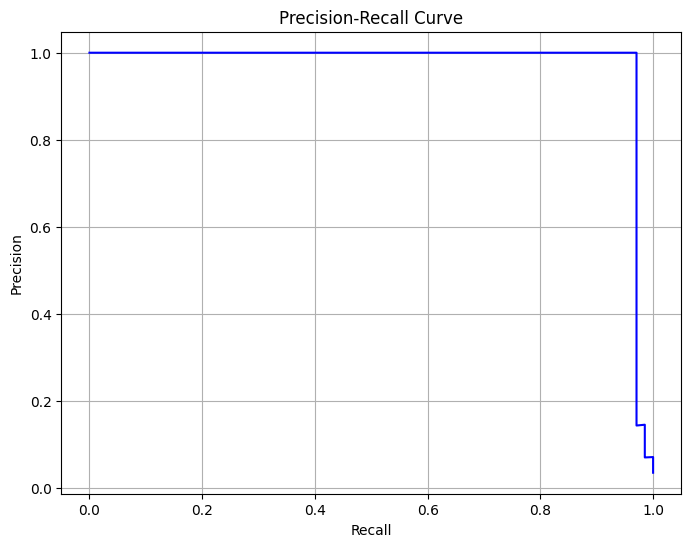

In [21]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color="blue")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [22]:
os.makedirs("../reports/plots", exist_ok=True)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.savefig("../reports/plots/precision_recall_curve.png")
plt.close()

In [23]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("../data/model_ready_dataset.csv")

In [25]:
print(df.shape)
print(df.columns.tolist())

(10000, 21)
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact', 'Machine failure']


In [26]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [27]:
X_model = X.copy()

In [28]:
X_model["timestamp"] = pd.to_datetime(
    X_model["timestamp"]
).astype("int64") // 10**9

In [29]:
print(X_model["Type"].unique())

[2 1 0]


In [30]:
X_model.columns = (
    X_model.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
    .str.replace(" ", "_", regex=False)
)

In [31]:
print(X_model.columns.tolist())

['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact']


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [33]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(random_state=42)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002922 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1747
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [35]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[1.53081075e-06 1.53149793e-06 4.06285541e-06 1.53295597e-06
 1.53078627e-06 1.54277730e-06 1.63540480e-06 1.80249148e-06
 1.53258225e-06 3.09227582e-06]


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [37]:
thresholds = np.arange(0.1, 1.0, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append([threshold, precision, recall, f1])

In [38]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison

,Threshold,Precision,Recall,F1 Score
0,0.10,1.0,0.970588,0.985075
1,0.15,1.0,0.970588,0.985075
2,0.20,1.0,0.970588,0.985075
3,0.25,1.0,0.970588,0.985075
4,0.30,1.0,0.970588,0.985075
5,0.35,1.0,0.970588,0.985075
6,0.40,1.0,0.970588,0.985075
7,0.45,1.0,0.970588,0.985075
8,0.50,1.0,0.970588,0.985075
9,0.55,1.0,0.970588,0.985075


In [39]:
best = comparison.loc[comparison["F1 Score"].idxmax()]

print(best)

Threshold    0.100000
Precision    1.000000
Recall       0.970588
F1 Score     0.985075
Name: 0, dtype: float64


In [40]:
import os

os.makedirs("../reports", exist_ok=True)

In [41]:
comparison.to_csv(
    "../reports/threshold_tuning_results.csv",
    index=False
)

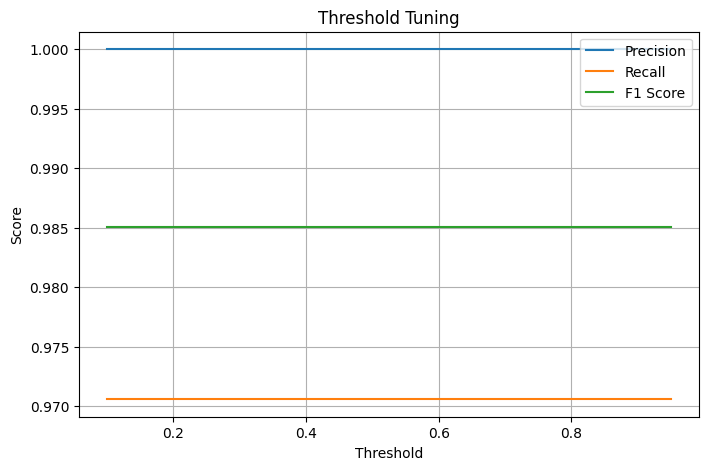

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    comparison["Threshold"],
    comparison["Precision"],
    label="Precision"
)

plt.plot(
    comparison["Threshold"],
    comparison["Recall"],
    label="Recall"
)

plt.plot(
    comparison["Threshold"],
    comparison["F1 Score"],
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")

plt.grid(True)
plt.legend()

plt.show()

In [43]:
os.makedirs("../static/images", exist_ok=True)

plt.savefig(
    "../static/images/threshold_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [44]:
best_threshold = best["Threshold"]

print("Best Threshold:", best_threshold)

Best Threshold: 0.1


In [46]:
os.makedirs("../models", exist_ok=True)

In [47]:
with open("../models/best_threshold.txt", "w") as f:
    f.write(str(best_threshold))